> **Note:** This environment variable is required for fully deterministic CuBLAS ops on CUDA >= 10.2 when `reproducible=True` is set below. Without it, PyTorch raises a `RuntimeError` instead of training deterministically. It must be set before `torch` is imported. See the [README FAQ](../../README.md#reproducibility-and-cublas_workspace_config) for details.

In [ ]:
%env CUBLAS_WORKSPACE_CONFIG=:16:8

# How To Use Varix

Varix is our implementation of a variational autoencoder.  
This tutorial follows the structure of our `Getting Started - Vanillix`, but is much less extensive, because  
our pipeline works similarly for different architectures, so here we focus only on Varix specifics.

**AUTOENCODIX** supports far more functionality than shown here, so we’ll also point to advanced tutorials where relevant.  

**IMPORTANT**

> This tutorial only shows the specifics of the Varix pipeline. If you're unfamiliar with general concepts,  
> we recommend following the [`Getting Started - Vanillix`](./Vanillix.ipynb) tutorial first.

## What You'll Learn

You’ll learn how to:

1. **Initialize** the pipeline and run the pipeline. <br><br>
2. Understand the Varix-specific **pipeline steps**. <br><br>
3. Access the Varix-specific **results** (mus, sigma, KL/MMD losses). <br><br>
4. **Visualize** outputs effectively. <br><br>
5. Apply **custom parameters**. <br><br>
6. **Save, load, and reuse** a trained pipeline. <br><br>

Let’s get started! 🚀


## Requirements 1: Be in the correct directory (execute below)


In [ ]:
import os

p = os.getcwd()
d = "autoencodix_package"
if d not in p:
    raise FileNotFoundError(f"'{d}' not found in path: {p}")
os.chdir(os.sep.join(p.split(os.sep)[: p.split(os.sep).index(d) + 1]))
print(f"Changed to: {os.getcwd()}")


Changed to: /home/alicia/dev/biomarker_autoencoder/autoencodix_package


## Requirements 2: Obtain tutorial data or use own data
We use real human lung single-cell RNA-seq data assembled from the [CZ CELLxGENE Census](https://cellxgene.cziscience.com/). It is hosted on Hugging Face Hub ([autoencodix/census-lung](https://huggingface.co/datasets/autoencodix/census-lung)) and is downloaded automatically in the cells below on first run — no manual download or placement into `data/raw` needed. The full dataset contains ~89,000 cells spanning four clearly distinguishable lung cell types (malignant cells, pulmonary alveolar type 2 cells, respiratory basal cells, alveolar macrophages). To keep this tutorial fast to run, we draw a balanced subsample of 2,000 cells per cell type below. Alternatively you can use your own single-cell dataset (Varix works with other datatypes, but in this example we expect single-cell data: `h5ad`).


In [ ]:
import numpy as np
import anndata as ad
import mudata

from huggingface_hub import hf_hub_download
from autoencodix.data.datapackage import DataPackage

sc_path = hf_hub_download(
    repo_id="autoencodix/census-lung", repo_type="dataset", filename="census_lung.h5ad"
)
full_adata = ad.read_h5ad(sc_path)

# Balanced subsample: 2,000 cells per cell type keeps the tutorial fast to run
# while keeping all four (well-separated) cell types equally represented.
N_PER_TYPE = 2000
rng = np.random.RandomState(42)
subsample_idx = []
for _, group in full_adata.obs.groupby("cell_type", observed=True):
    n = min(N_PER_TYPE, len(group))
    subsample_idx.extend(rng.choice(group.index.values, size=n, replace=False))

adata = full_adata[subsample_idx].copy()
print(adata.obs["cell_type"].value_counts())

# Instead of passing a pandas DataFrame, we wrap the AnnData in a MuData object
# inside our custom DataPackage structure, this time with single-cell data.
sc_data = DataPackage()
sc_data.multi_sc = {"multi_sc": mudata.MuData({"rna": adata})}


## 1) Initialize and Run Varix

We set a few custom parameters of the config file. For a deep dive into the config object, see:  

[`Tutorials/DeepDives/ConfigTutorial.ipynb`](../DeepDives/ConfigTutorial.ipynb)

#### 1.1 The Dataset

We use the `sc_data` `DataPackage` prepared above (the census-lung dataset wrapped in an `AnnData`/`MuData` object) and color the downstream plots by the `cell_type` metadata column.


In [ ]:
from autoencodix.configs.varix_config import VarixConfig
from autoencodix.configs.default_config import DataCase, DataConfig, DataInfo
import autoencodix as acx

# Varix has its own config class
# with an additional loss term: either Kullback-Leibler (KL) or Maximum Mean Discrepancy (MMD)
my_config = VarixConfig(
    learning_rate=0.001,
    epochs=30,
    checkpoint_interval=5,
    default_vae_loss="kl",  # 'kl' or 'mmd' possible
    anneal_function="logistic-mid",
    k_filter=2000,
    data_case=DataCase.MULTI_SINGLE_CELL,
    annotation_columns=["cell_type"],
    data_config=DataConfig(
        data_info={"multi_sc": DataInfo(is_single_cell=True, data_type="NUMERIC")},
    ),
)

print("\nStarting Pipeline")
print("-" * 50)
varix = acx.Varix(data=sc_data, config=my_config)
result = varix.run()

## 2) Specific Varix Steps (with Beta Annealing Explanation)

The pipeline (`run`) does not have Varix-specific steps.  
It calls:
- preprocess  
- fit  
- predict  
- visualize  

However, the fit step works slightly differently because we have a second loss term for the distribution loss.  
This loss term can be weighted with a hyperparameter `beta` (set via config), and the weighting can be changed during training depending on the epoch via **beta annealing**.  

**Beta annealing** gradually increases the weight of the VAE distribution loss during training.  
For example, you might start with `beta=0` to let the reconstruction loss dominate early, and then gradually increase `beta` to 1 as training progresses.  
Different annealing strategies are supported, including logistic schedules, multi-phase linear or logarithmic schedules, and constant or no annealing.  
This allows more stable training and better latent space learning, especially for early epochs.

Since we're working with a variational autoencoder, we can call an additional pipeline step, `sample_latent_space`.  
The latent space inside the pipeline is sampled once from the fitted normal distribution, with one set of `mu` and `sigma` per latent dimension.  

By default, we sample from the trained model and the test data, but you can specify the split and epoch.

**ATTENTION**   <br><br>
> If you want to sample from a different split (uses data from that split as input) or epoch (uses the model at this epoch), you need to ensure you select an epoch that was checkpointed (see `checkpoint_interval` config parameter).


In [3]:
print(f"Annealing Strategy for training was: {my_config.anneal_function}")
print(f"beta hyperparam was set to: {my_config.beta}")
print("\n")
print("Starting sampling different latent spaces")
print("-"*50)
latent_spaces_sampled = varix.sample_latent_space(n_samples=100)
print(f"sampled latent space shape: {latent_spaces_sampled.shape}")

# or
sampled = varix.sample_latent_space(split="train", epoch=4,n_samples=50)
sampled

Annealing Strategy for training was: logistic-mid
beta hyperparam was set to: 0.1


Starting sampling different latent spaces
--------------------------------------------------
sampled latent space shape: torch.Size([100, 16])


tensor([[ 0.9430,  2.0583,  1.6290,  1.4118,  3.0953, -0.2439,  0.5837,  3.1268,
          1.2154,  2.7030,  1.2484,  2.9225,  2.0729,  3.0561,  2.9467,  1.0219],
        [ 0.9076,  3.3573,  1.1231,  1.7728,  3.0758,  1.1500,  2.4252,  2.1990,
          1.7451,  3.9200,  0.5884,  2.7938,  2.3263,  3.6288,  3.7844,  2.3264],
        [ 1.5086,  3.6335,  3.9868,  2.6657,  4.1079,  1.0468,  2.2605,  1.0789,
          2.1675,  0.8027, -0.2446,  3.8527,  3.7345,  2.0828,  2.9376,  2.5120],
        [-0.0452,  2.0713,  0.1617,  2.5629,  2.2671, -1.0041,  3.1609,  0.2413,
          2.9624,  3.2907,  0.5396,  4.6352,  3.6772,  3.3980,  3.1260,  1.5365],
        [-1.7586,  3.2197,  0.1883,  0.6308,  3.9375, -1.8809,  1.7806,  1.1545,
          1.9622,  2.8209, -0.2994,  2.0133,  2.7295,  2.0333,  5.8884,  3.5070],
        [ 1.7308,  4.0183,  0.2277,  1.7144,  4.3185, -1.5279,  0.7580,  1.3412,
          1.4885,  2.6263, -0.1928,  2.5573,  3.3156,  3.7370,  1.3219,  3.4953],
        [ 2.0280,  3.5

## 3) Inspect Varix-Specific Results

In addition to the results that the Vanillix pipeline provided, we can access:
- Fitted distribution parameters `mu` and `sigma`  
- `total`, `reconstruction`, and `vae` losses  
- `anneal_factor`  

A note on the different loss types:  
For our variational autoencoder, the total loss consists of a reconstruction loss and a distribution loss (i.e., KL-divergence).  
To investigate these losses, the `result` object has the attribute `sub_losses`.  
This is a `LossRegistry` with the name of the loss as the key, and the value is a `TrainingDynamics` object, which can be accessed in the same way as for the Vanillix results.

For more details, check [`Tutorials/DeepDives/PipelineOutputTutorial.ipynb`](../DeepDives/PipelineOutputTutorial.ipynb).


In [4]:
sub_losses = result.sub_losses
print("Sub Losses:")
print(f"keys: {sub_losses.keys()}")
print("\n")
recon_dyn = sub_losses.get(key="recon_loss")
print("Value of reconstruction loss in epoch 4 for train split")
print(recon_dyn.get(split="train", epoch=4))

Sub Losses:
keys: dict_keys(['recon_loss', 'var_loss', 'anneal_factor', 'effective_beta_factor'])


Value of reconstruction loss in epoch 4 for train split
1772.7589341517858


## 4) Show Visualizations

This follows the standard pipeline process and can be done by calling `show_result()`.  
We can also add the keyword argument `params` to `show_result()`, which colors the plots according to a metadata column.


Creating plots ...


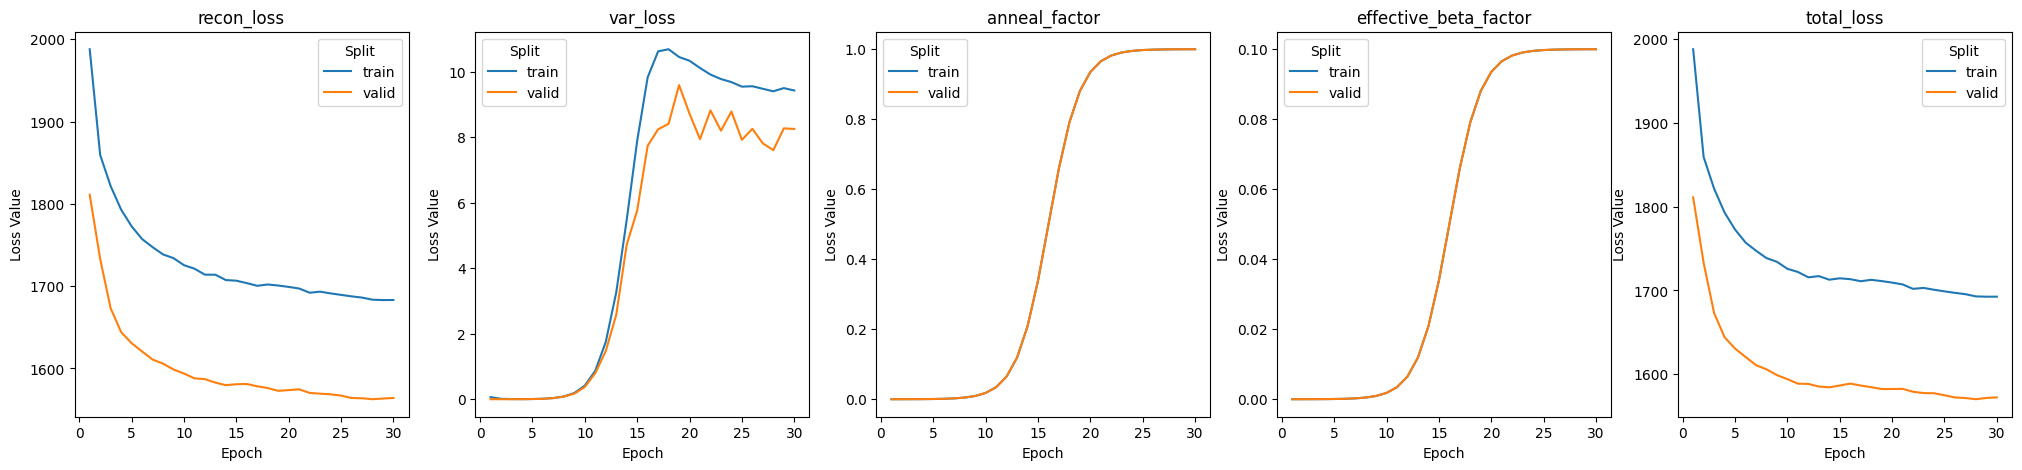

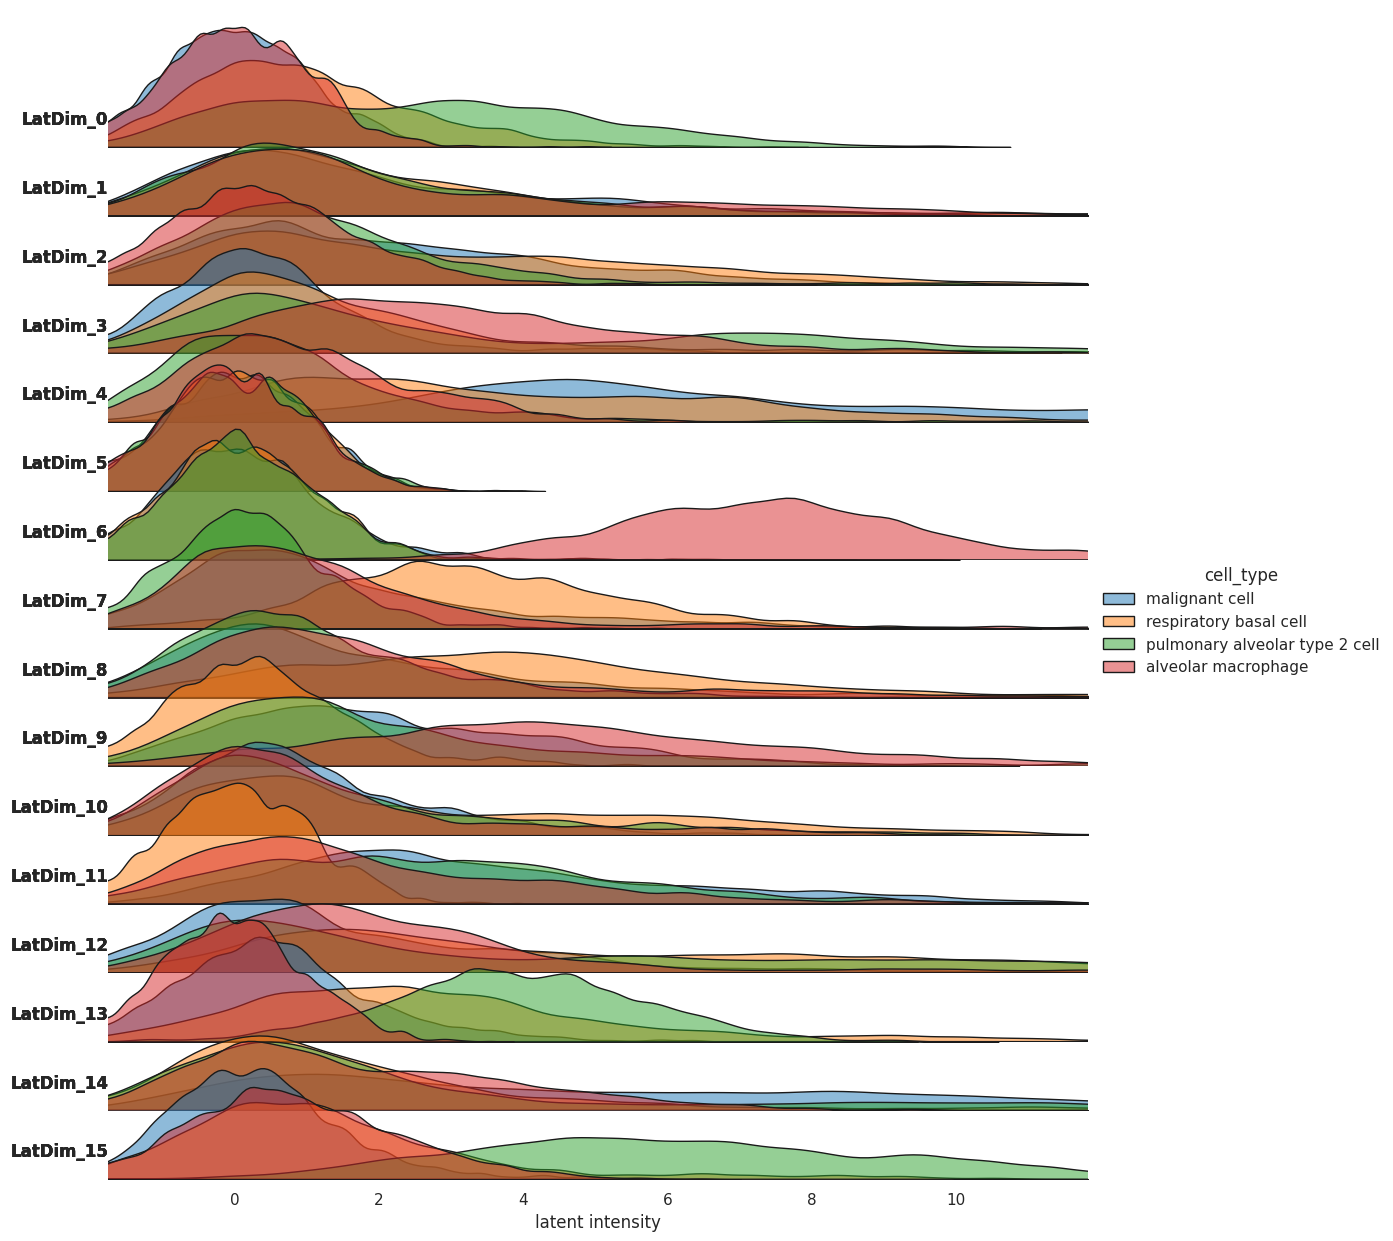

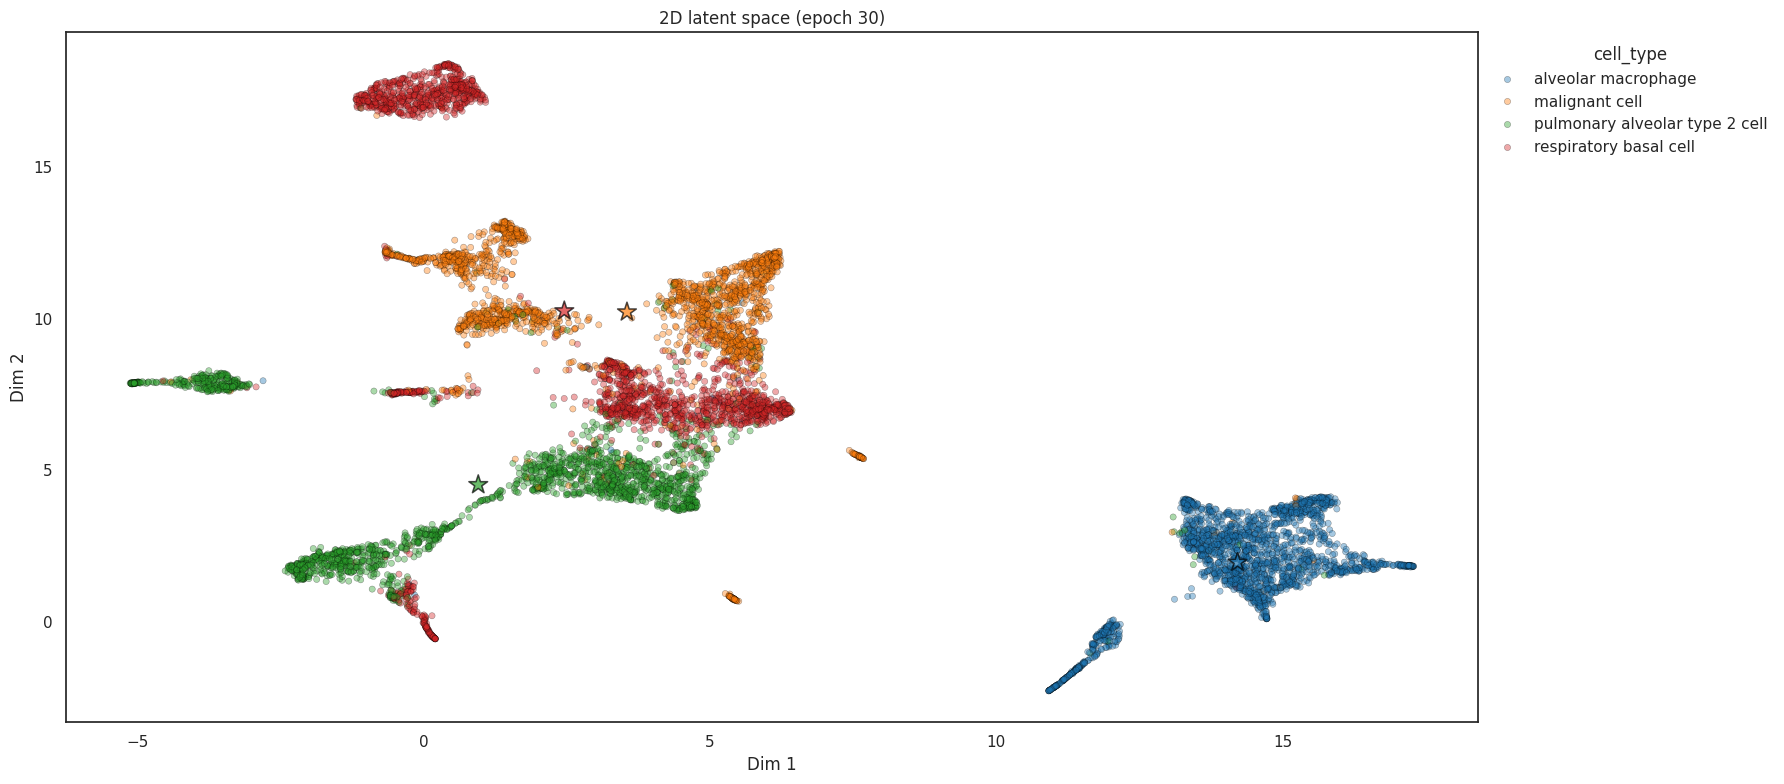

In [5]:
varix.result.datasets.test.metadata.head()

varix.show_result(params=["cell_type"])

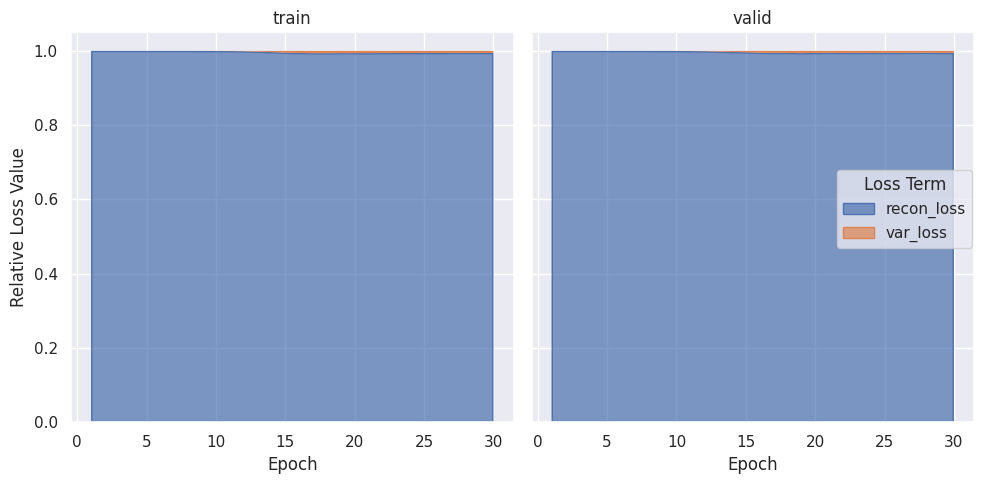

In [6]:
varix.visualizer.show_loss(plot_type="relative")

In [7]:
# A quick look at the real metadata available for coloring plots:
adata.obs[["cell_type", "disease", "sex"]].value_counts()


cell_type                       disease              sex    
malignant cell                  lung adenocarcinoma  male       1196
alveolar macrophage             normal               male       1012
respiratory basal cell          normal               unknown     894
pulmonary alveolar type 2 cell  normal               male        792
                                                     female      765
malignant cell                  lung adenocarcinoma  female      730
respiratory basal cell          cystic fibrosis      unknown     542
alveolar macrophage             normal               female      539
                                                     unknown     449
pulmonary alveolar type 2 cell  normal               unknown     443
respiratory basal cell          normal               male        381
                                                     female      183
malignant cell                  lung adenocarcinoma  unknown      74
Name: count, dtype: int64

## 5) Customize Varix

To customize the behavior of our pipeline, you adjust the configuration.  
There are two ways to work with the config:

1. Create a customized instance of the config class.  
2. Provide a `yaml` file and use the config class to read it.  

We will focus on option 1 and show a few examples. For a deeper dive into configurations, please refer to [`Tutorials/DeepDives/ConfigTutorial.ipynb`](../DeepDives/ConfigTutorial.ipynb) <br>

In this section, we demonstrate some Varix-specific parameters:
- Loss term  
- Beta  
- Annealing strategy  
- Retrieve information about all config parameters


In [8]:
from autoencodix.configs import VarixConfig

custom_config = VarixConfig(
    default_vae_loss="mmd",
    beta=1.5,
    anneal_function="3phase-linear",
    data_case=DataCase.MULTI_SINGLE_CELL,
    epochs=50,
    k_filter=2000,
    annotation_columns=["cell_type"],
    data_config=DataConfig(
        data_info={"multi_sc": DataInfo(is_single_cell=True, data_type="NUMERIC")},
    ),
)

custom_varix = acx.Varix(config=custom_config, data=sc_data)
result = custom_varix.run()


in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
mudata: View of MuData object with n_obs × n_vars = 8000 × 8189
  var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
  1 modality
    rna:	8000 x 8189
      obs:	'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'n_genes'
      var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'


Processing 1 MuData objects: ['multi_sc']
Processing train modality: multi_sc


Processing valid split
Processing valid modality: multi_sc
Processing test split
Processing test modality: multi_sc


Epoch 1 - Train Loss: 1982.2003
Sub-losses: recon_loss: 1982.2003, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 1 - Valid Loss: 1893.5452
Sub-losses: recon_loss: 1893.5452, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000


Epoch 2 - Train Loss: 1831.7209
Sub-losses: recon_loss: 1831.7209, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Valid Loss: 1833.5430
Sub-losses: recon_loss: 1833.5430, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000


...

Epoch 46 - Train Loss: 1673.9595
Sub-losses: recon_loss: 1658.3272, var_loss: 15.6323, anneal_factor: 1.0000, effective_beta_factor: 1.5000
Epoch 46 - Valid Loss: 1715.0471
Sub-losses: recon_loss: 1701.6574, var_loss: 13.3897, anneal_factor: 1.0000, effective_beta_factor: 1.5000


Epoch 47 - Train Loss: 1671.4804
Sub-losses: recon_loss: 1655.6537, var_loss: 15.8267, anneal_factor: 1.0000, effective_beta_factor: 1.5000
Epoch 47 - Valid Loss: 1716.1658
Sub-losses: recon_loss: 1702.1375, var_loss: 14.0283, anneal_factor: 1.0000, effective_beta_factor: 1.5000


Epoch 48 - Train Loss: 1669.8114
Sub-losses: recon_loss: 1654.1727, var_loss: 15.6387, anneal_factor: 1.0000, effective_beta_factor: 1.5000
Epoch 48 - Valid Loss: 1714.2166
Sub-losses: recon_loss: 1700.0976, var_loss: 14.1190, anneal_factor: 1.0000, effective_beta_factor: 1.5000


Epoch 49 - Train Loss: 1668.4940
Sub-losses: recon_loss: 1653.0692, var_loss: 15.4248, anneal_factor: 1.0000, effective_beta_factor: 1.5000
Epoch 49 - Valid Loss: 1712.1406
Sub-losses: recon_loss: 1698.4070, var_loss: 13.7336, anneal_factor: 1.0000, effective_beta_factor: 1.5000


Epoch 50 - Train Loss: 1668.5500
Sub-losses: recon_loss: 1653.3846, var_loss: 15.1654, anneal_factor: 1.0000, effective_beta_factor: 1.5000
Epoch 50 - Valid Loss: 1714.2114
Sub-losses: recon_loss: 1700.4264, var_loss: 13.7851, anneal_factor: 1.0000, effective_beta_factor: 1.5000
Processed 32 / 1600 samples
Processed 64 / 1600 samples
Processed 96 / 1600 samples
Processed 128 / 1600 samples
Processed 160 / 1600 samples
Processed 192 / 1600 samples
Processed 224 / 1600 samples
Processed 256 / 1600 samples
Processed 288 / 1600 samples
Processed 320 / 1600 samples
Processed 352 / 1600 samples
Processed 384 / 1600 samples
Processed 416 / 1600 samples
Processed 448 / 1600 samples
Processed 480 / 1600 samples
Processed 512 / 1600 samples
Processed 544 / 1600 samples
Processed 576 / 1600 samples
Processed 608 / 1600 samples
Processed 640 / 1600 samples
Processed 672 / 1600 samples
Processed 704 / 1600 samples
Processed 736 / 1600 samples
Processed 768 / 1600 samples
Processed 800 / 1600 sample

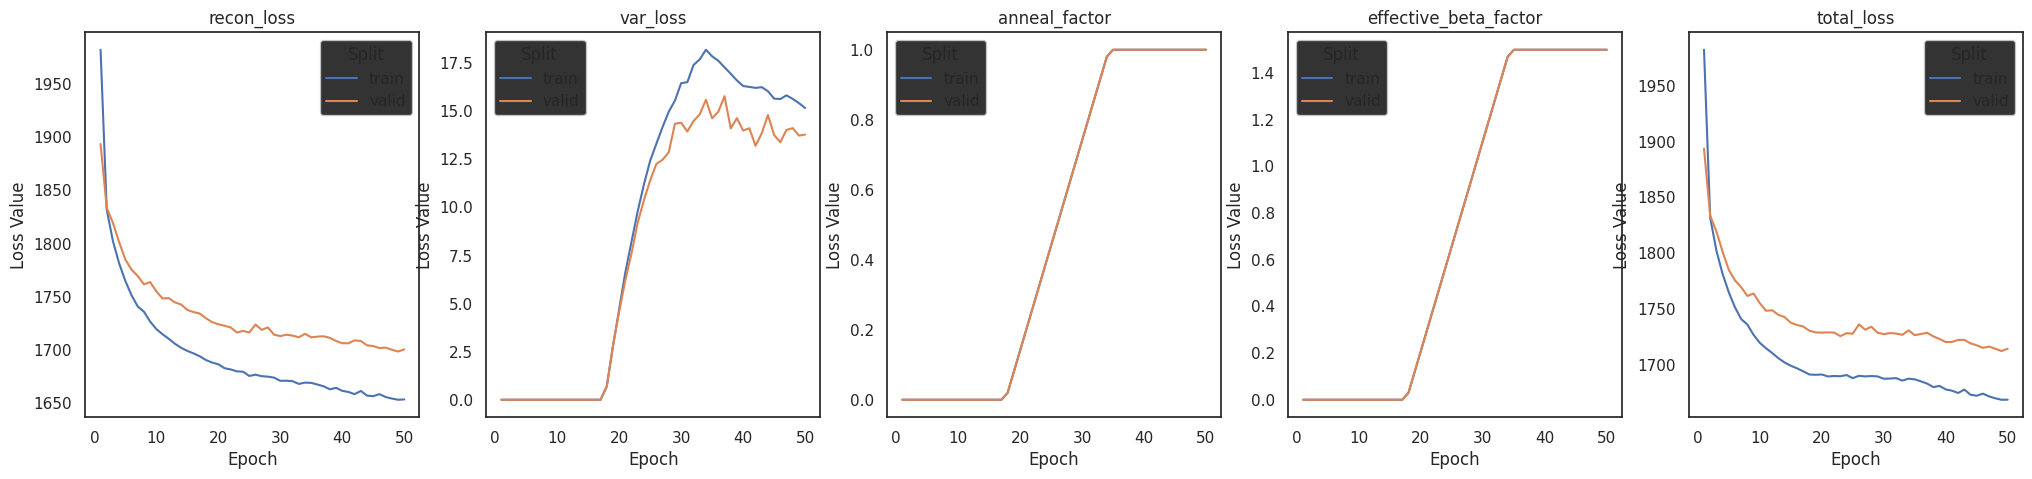

In [9]:
custom_varix.visualizer.show_loss(plot_type="absolute")

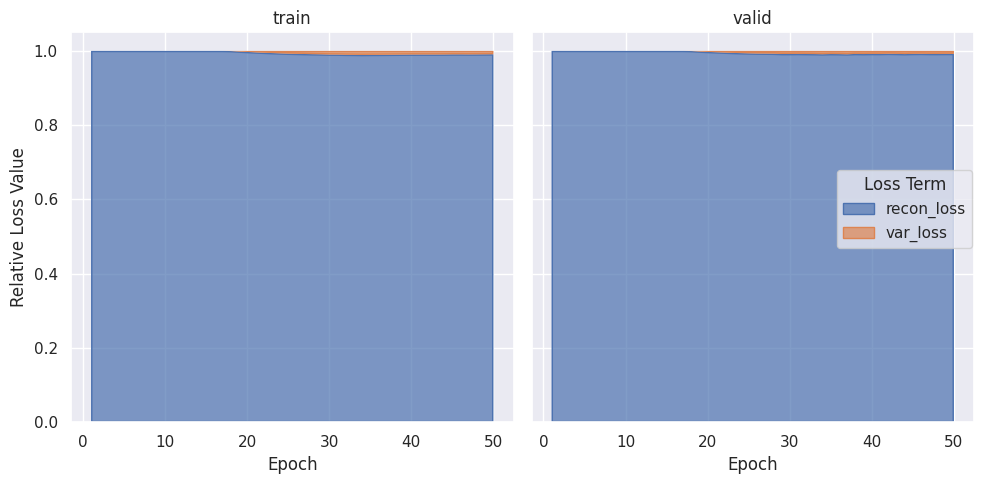

In [10]:
custom_varix.visualizer.show_loss(plot_type="relative")

## 6) Re-use, Save, Load
There are not `Varix` specific steps here. See the `Getting Started - Vanillix` for details. Below is a basic save/load usecase:

Preprocessor saved successfully.


saving memory efficient
Pipeline object saved successfully.
PKL files: ['tutorial_res/varix_preprocessor.pkl', 'tutorial_res/ontix.pkl', 'tutorial_res/maskix_preprocessor.pkl', 'tutorial_res/ontix_preprocessor.pkl']
Model files: ['tutorial_res/varix_model.pth', 'tutorial_res/ontix_model.pth', 'tutorial_res/maskix_model.pth']
Attempting to load a pipeline from tutorial_res/varix...
Pipeline object loaded successfully. Actual type: Varix
Preprocessor loaded successfully.
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>


mudata: View of MuData object with n_obs × n_vars = 8000 × 8189
  var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
  1 modality
    rna:	8000 x 8189
      obs:	'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'n_genes'
      var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
Processing 1 MuData objects: ['multi_sc']
Processing test split
Processing test modality: multi_sc


Processed 32 / 8000 samples
Processed 64 / 8000 samples
Processed 96 / 8000 samples
Processed 128 / 8000 samples
Processed 160 / 8000 samples
Processed 192 / 8000 samples
Processed 224 / 8000 samples
Processed 256 / 8000 samples
Processed 288 / 8000 samples
Processed 320 / 8000 samples
Processed 352 / 8000 samples
Processed 384 / 8000 samples
Processed 416 / 8000 samples
Processed 448 / 8000 samples
Processed 480 / 8000 samples
Processed 512 / 8000 samples
Processed 544 / 8000 samples
Processed 576 / 8000 samples
Processed 608 / 8000 samples
Processed 640 / 8000 samples
Processed 672 / 8000 samples
Processed 704 / 8000 samples
Processed 736 / 8000 samples
Processed 768 / 8000 samples
Processed 800 / 8000 samples
Processed 832 / 8000 samples
Processed 864 / 8000 samples
Processed 896 / 8000 samples
Processed 928 / 8000 samples
Processed 960 / 8000 samples
Processed 992 / 8000 samples
Processed 1024 / 8000 samples
Processed 1056 / 8000 samples
Processed 1088 / 8000 samples
Processed 1120

Processed 4960 / 8000 samples
Processed 4992 / 8000 samples
Processed 5024 / 8000 samples
Processed 5056 / 8000 samples
Processed 5088 / 8000 samples
Processed 5120 / 8000 samples
Processed 5152 / 8000 samples
Processed 5184 / 8000 samples
Processed 5216 / 8000 samples
Processed 5248 / 8000 samples
Processed 5280 / 8000 samples
Processed 5312 / 8000 samples
Processed 5344 / 8000 samples
Processed 5376 / 8000 samples
Processed 5408 / 8000 samples
Processed 5440 / 8000 samples
Processed 5472 / 8000 samples
Processed 5504 / 8000 samples
Processed 5536 / 8000 samples
Processed 5568 / 8000 samples
Processed 5600 / 8000 samples
Processed 5632 / 8000 samples
Processed 5664 / 8000 samples
Processed 5696 / 8000 samples
Processed 5728 / 8000 samples
Processed 5760 / 8000 samples
Processed 5792 / 8000 samples
Processed 5824 / 8000 samples
Processed 5856 / 8000 samples
Processed 5888 / 8000 samples
Processed 5920 / 8000 samples
Processed 5952 / 8000 samples
Processed 5984 / 8000 samples
Processed 

Creating plots ...


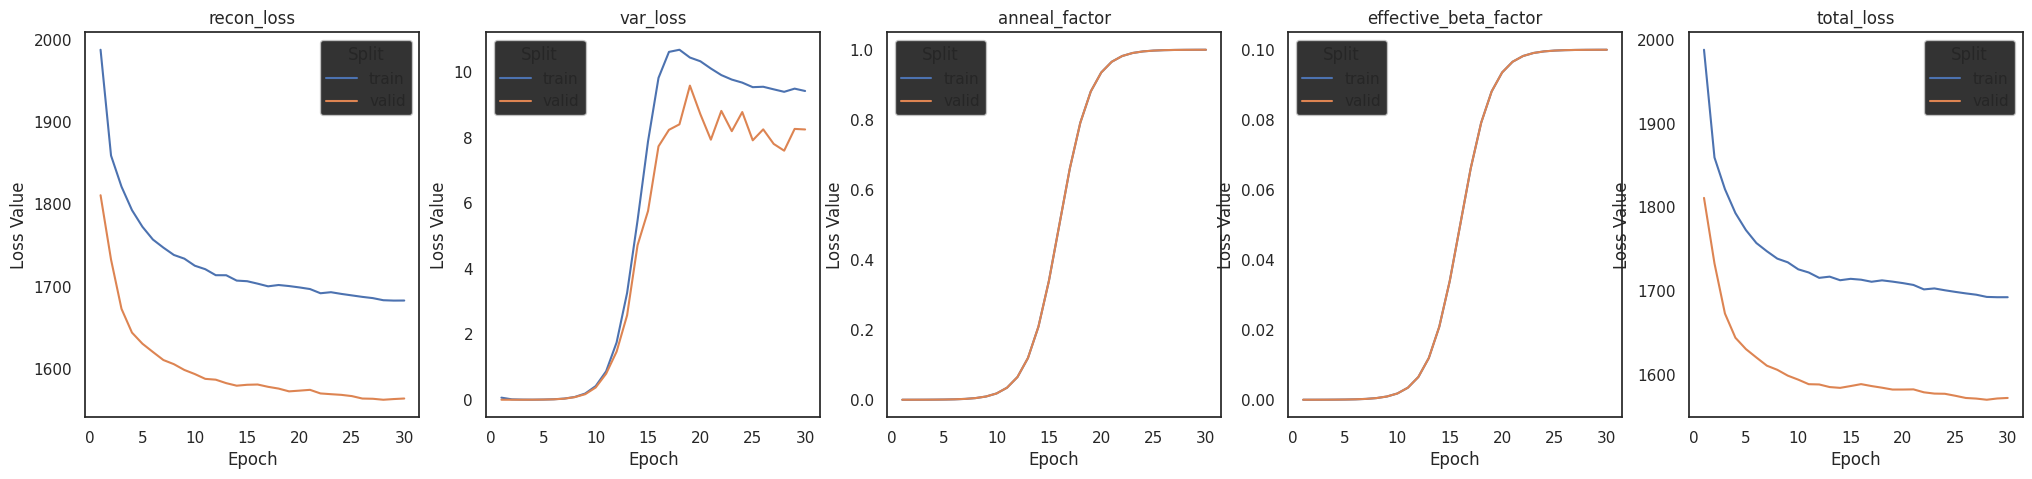

/home/alicia/dev/biomarker_autoencoder/autoencodix_package/src/autoencodix/utils/_result.py:348: UserWarning: Could not retrieve latent representations for epoch 29 and split 'train'. Returning empty DataFrame. This may be due to missing data in the Result object or incorrect keys.


  warnings.warn(
/home/alicia/dev/biomarker_autoencoder/autoencodix_package/src/autoencodix/utils/_result.py:348: UserWarning: Could not retrieve latent representations for epoch 29 and split 'valid'. Returning empty DataFrame. This may be due to missing data in the Result object or incorrect keys.


  warnings.warn(


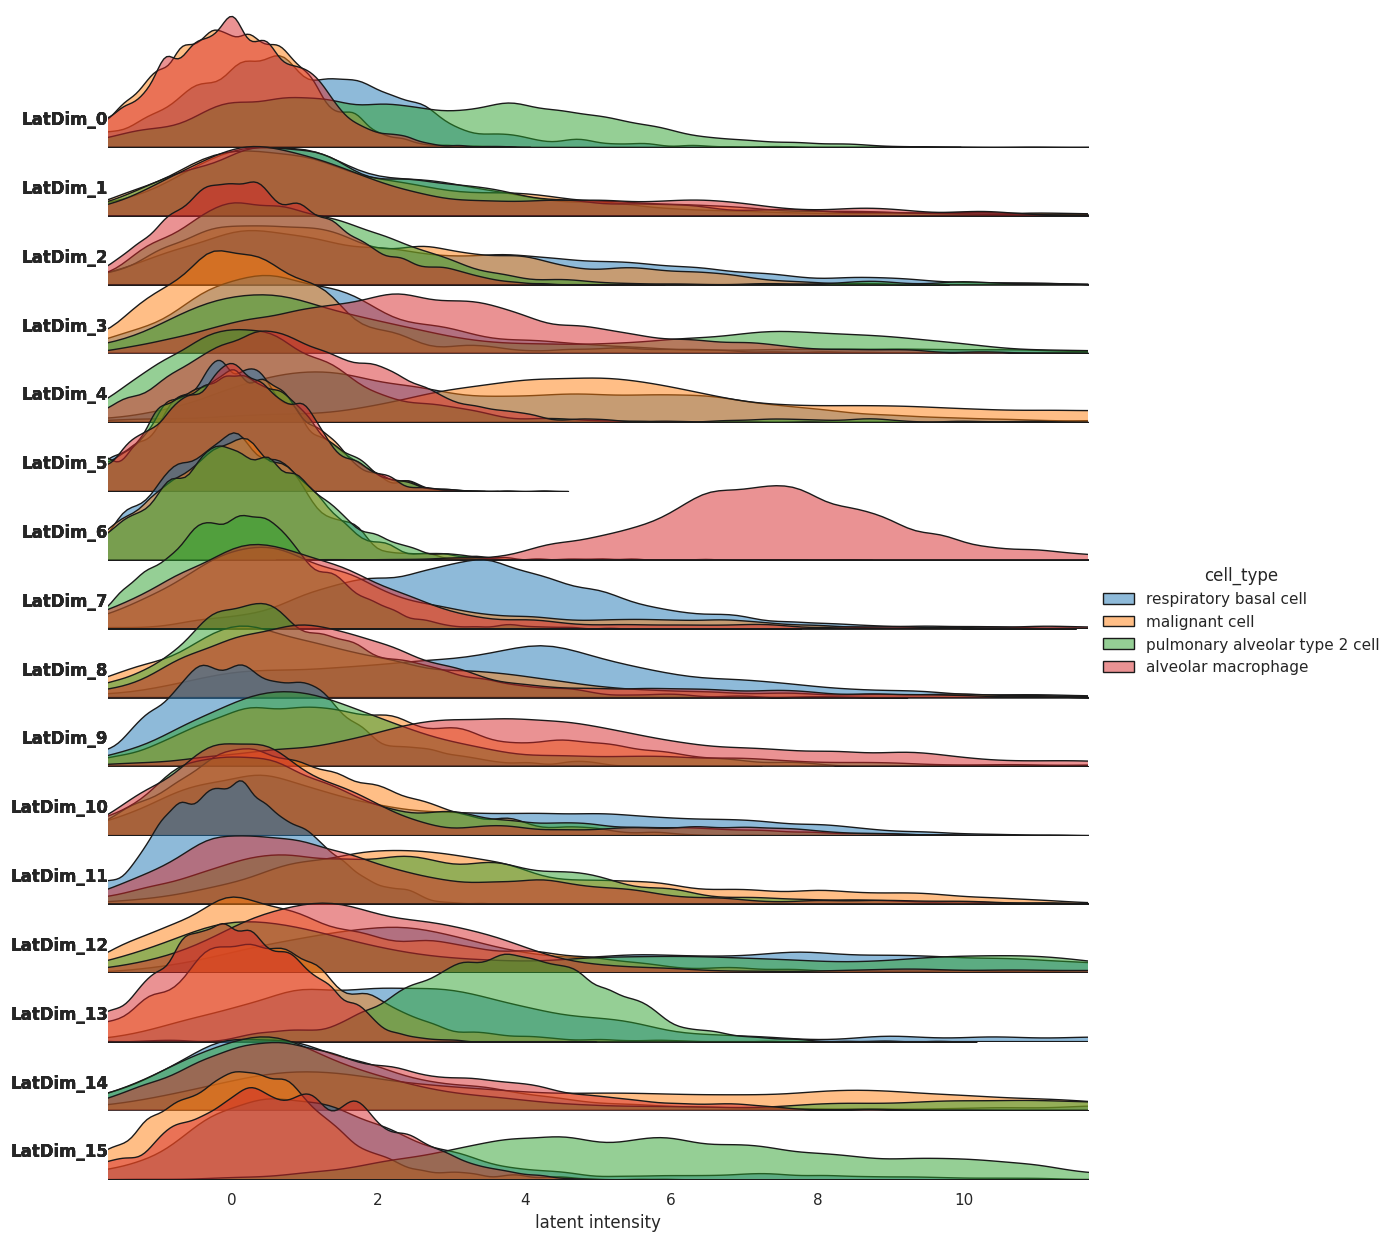

/home/alicia/dev/biomarker_autoencoder/autoencodix_package/src/autoencodix/utils/_result.py:348: UserWarning: Could not retrieve latent representations for epoch 29 and split 'train'. Returning empty DataFrame. This may be due to missing data in the Result object or incorrect keys.


  warnings.warn(
/home/alicia/dev/biomarker_autoencoder/autoencodix_package/src/autoencodix/utils/_result.py:348: UserWarning: Could not retrieve latent representations for epoch 29 and split 'valid'. Returning empty DataFrame. This may be due to missing data in the Result object or incorrect keys.


  warnings.warn(


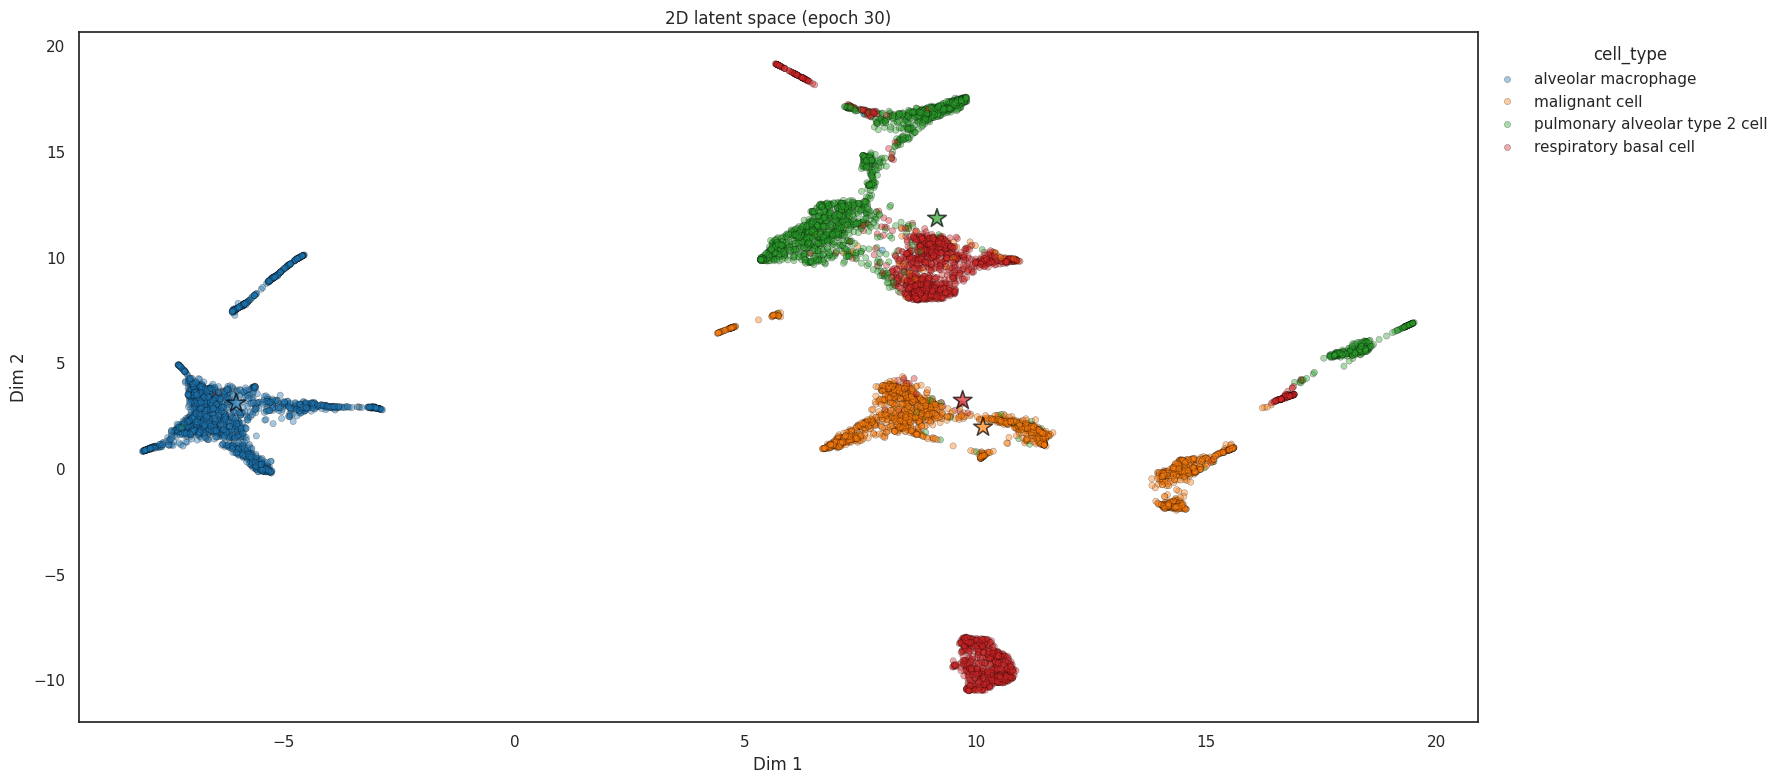

In [11]:
import os
import glob
# use a filename without extension, we handle this internally
outpath = os.path.join("tutorial_res", "varix")
varix.save(file_path=outpath, save_all=False)

folder = os.path.dirname(outpath)
pkl_files = glob.glob(os.path.join(folder, "*.pkl"))
model_files = glob.glob(os.path.join(folder, "*.pth"))

print("PKL files:", pkl_files)
print("Model files:", model_files)

# the load functionality automatically will build the pipeline object out of the three saved files
varix_loaded = acx.Varix.load(outpath)
varix_loaded.predict(data=sc_data)
varix_loaded.visualize()
varix_loaded.show_result(params=["cell_type"])

In [12]:
varix_loaded.evaluate(
	params=["cell_type"],
	split_type="CV-5",
	)

Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: cell_type


/home/alicia/dev/biomarker_autoencoder/autoencodix_package/src/autoencodix/utils/_result.py:348: UserWarning: Could not retrieve latent representations for epoch 29 and split 'train'. Returning empty DataFrame. This may be due to missing data in the Result object or incorrect keys.


  warnings.warn(
/home/alicia/dev/biomarker_autoencoder/autoencodix_package/src/autoencodix/utils/_result.py:348: UserWarning: Could not retrieve latent representations for epoch 29 and split 'valid'. Returning empty DataFrame. This may be due to missing data in the Result object or incorrect keys.


  warnings.warn(


/home/alicia/dev/biomarker_autoencoder/autoencodix_package/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/alicia/dev/biomarker_autoencoder/autoencodix_package/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solve

/home/alicia/dev/biomarker_autoencoder/autoencodix_package/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/alicia/dev/biomarker_autoencoder/autoencodix_package/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solve

Result Object Public Attributes:
------------------------------
latentspaces: TrainingDynamics object
sample_ids: TrainingDynamics object
reconstructions: TrainingDynamics object
mus: TrainingDynamics object
sigmas: TrainingDynamics object
losses: TrainingDynamics object
sub_losses: LossRegistry(_losses={'recon_loss': TrainingDynamics(), 'var_loss': TrainingDynamics(), 'anneal_factor': TrainingDynamics(), 'effective_beta_factor': TrainingDynamics()})
preprocessed_data: Tensor of shape (0,)
model: VarixArchitecture
model_checkpoints: TrainingDynamics object
datasets: DatasetContainer(train=None, valid=None, test=None)
new_datasets: DatasetContainer(train=<autoencodix.data._numeric_dataset.NumericDataset object at 0x7aeb51b885b0>, valid=None, test=<autoencodix.data._numeric_dataset.NumericDataset object at 0x7aeb51b885e0>)
adata_latent: AnnData object with n_obs × n_vars = 8000 × 16
    uns: 'var_names'
final_reconstruction: MuData object with n_obs × n_vars = 8000 × 2000
  1 modality
  

Showing plot for ML algorithm: LogisticRegression


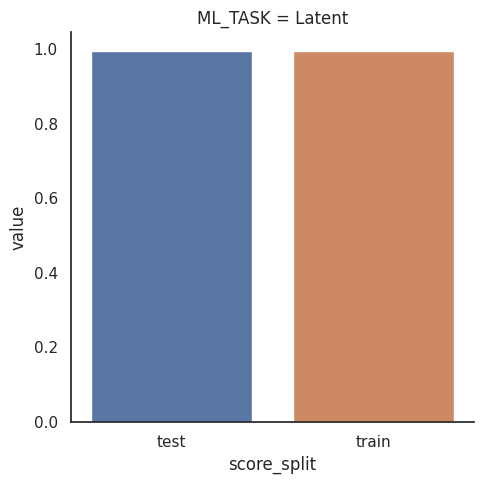

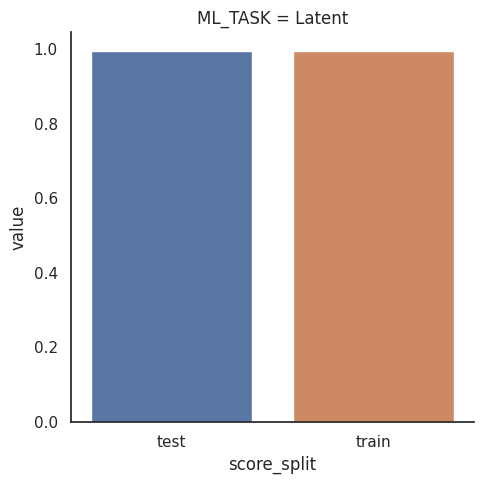

In [13]:
varix_loaded.visualizer.show_evaluation(
	param="cell_type",
	metric="roc_auc_ovo",
)